# Hybrid Movie Recommendation System using MovieLens 100K Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from surprise import Dataset, Reader, SVD

## Load MovieLens 100K Dataset

In [ ]:
# Load ratings
ratings = pd.read_csv(
    'ml-100k/u.data',
    sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp'],
    engine='python'
)

In [ ]:
# Load all columns from u.item (including genres and IMDb_URL)
movies = pd.read_csv(
    'ml-100k/u.item',
    sep='|',
    encoding='latin-1',
    names=[
        'movieId', 'title', 'release_date', 'video_release_date', 'IMDb_URL',
        'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
        'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
        'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
    ]
)

In [ ]:
# Convert movieId to int just in case
ratings['movieId'] = ratings['movieId'].astype(int)
movies['movieId'] = movies['movieId'].astype(int)

# Merge ratings with movies
df = pd.merge(ratings, movies, on='movieId')

## Content-Based Filtering (TF-IDF on Movie Titles and Genres)

In [ ]:
movies['content'] = movies['title'] + ' ' + movies.drop(columns=['movieId', 'title', 'release_date', 'IMDb_URL']).apply(lambda x: ' '.join(x.astype(str)), axis=1)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['content'])

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cbf_df = pd.DataFrame(cosine_sim, index=movies['movieId'], columns=movies['movieId'])

## Collaborative Filtering (SVD using Surprise)

In [ ]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [ ]:
trainset = data.build_full_trainset()
algo = SVD()
algo.fit(trainset)

## Hybrid Recommendation Function

In [ ]:
def get_recommendations(user_id, algo, cbf_df, movies, ratings, top_n=10):
    user_rated = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    candidates = [m for m in movies['movieId'] if m not in user_rated]
    recs = []

    for movie_id in candidates:
        try:
            pred = algo.predict(user_id, movie_id).est
            cbf_score = cbf_df.loc[movie_id].drop(user_rated, errors='ignore').mean() if movie_id in cbf_df.index else 0
            hybrid_score = 0.7 * pred + 0.3 * cbf_score
            recs.append((movie_id, hybrid_score))
        except:
            continue

    recs = sorted(recs, key=lambda x: x[1], reverse=True)[:top_n]
    
    # Keep both movieId and score
    recommended = pd.DataFrame(recs, columns=['movieId', 'Hybrid Score'])
    recommended = recommended.merge(movies[['movieId', 'title', 'IMDb_URL'] + [col for col in movies.columns if col not in ['movieId', 'title', 'IMDb_URL']]], on='movieId', how='left')
    
    return recommended


## Example: Get Recommendations for User 1

In [ ]:
user_id = 1
recommended_movies = get_recommendations(user_id, algo, cbf_df, movies, ratings)
print(recommended_movies)

   movieId  Hybrid Score                                              title  \
0      603      3.430413                                 Rear Window (1954)   
1      474      3.312491  Dr. Strangelove or: How I Learned to Stop Worr...   
2      520      3.267821                           Great Escape, The (1963)   
3      511      3.254278                          Lawrence of Arabia (1962)   
4      661      3.213292                                   High Noon (1952)   
5      657      3.194510                   Manchurian Candidate, The (1962)   
6      483      3.191487                                  Casablanca (1942)   
7     1142      3.185739                          When We Were Kings (1996)   
8      709      3.179344                           Strictly Ballroom (1992)   
9      285      3.175225                              Secrets & Lies (1996)   

                                            IMDb_URL release_date  \
0  http://us.imdb.com/M/title-exact?Rear%20Window...  01-Jan-

## Visualization of Hybrid Scores

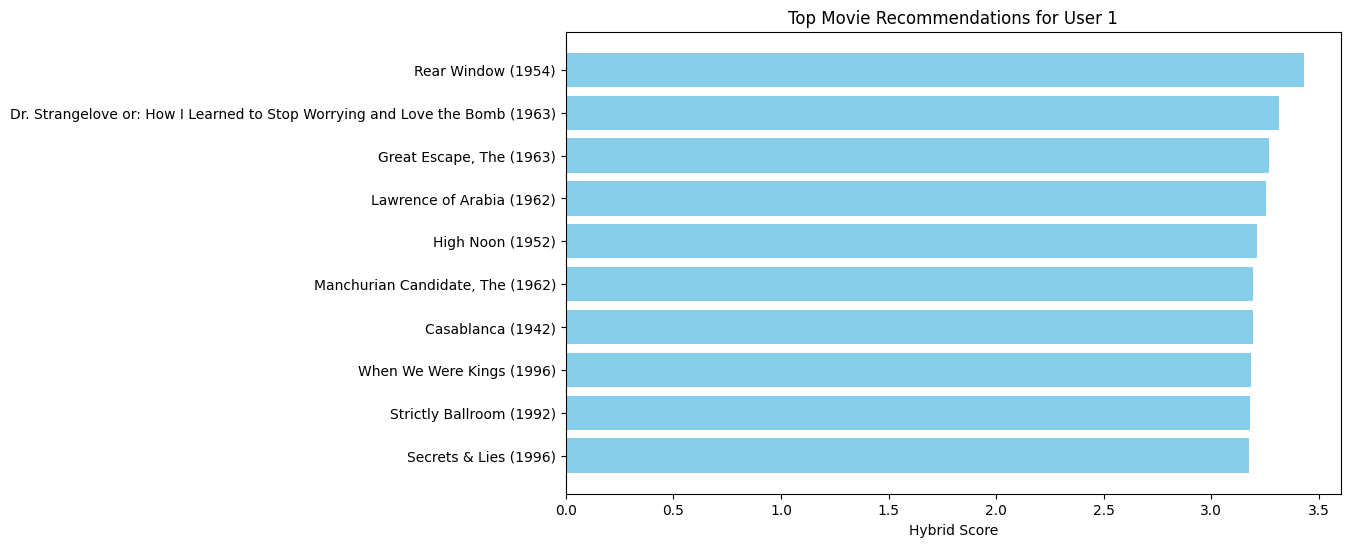

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(recommended_movies['title'], recommended_movies['Hybrid Score'], color='skyblue')
plt.xlabel('Hybrid Score')
plt.title(f'Top Movie Recommendations for User {user_id}')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import pickle

# Save the trained SVD model
with open("svd_model.pkl", "wb") as f:
    pickle.dump(algo, f)


In [ ]:
# Save the content-based filtering similarity matrix
cbf_df.to_pickle("cbf_matrix.pkl")


In [ ]:
print(movies['IMDb_URL'].head(10))


0    http://us.imdb.com/M/title-exact?Toy%20Story%2...
1    http://us.imdb.com/M/title-exact?GoldenEye%20(...
2    http://us.imdb.com/M/title-exact?Four%20Rooms%...
3    http://us.imdb.com/M/title-exact?Get%20Shorty%...
4    http://us.imdb.com/M/title-exact?Copycat%20(1995)
5    http://us.imdb.com/Title?Yao+a+yao+yao+dao+wai...
6    http://us.imdb.com/M/title-exact?Twelve%20Monk...
7       http://us.imdb.com/M/title-exact?Babe%20(1995)
8    http://us.imdb.com/M/title-exact?Dead%20Man%20...
9    http://us.imdb.com/M/title-exact?Richard%20III...
Name: IMDb_URL, dtype: object


## 📊 SVD Model Evaluation: RMSE and MAE

In [ ]:

from surprise.model_selection import train_test_split
from surprise import accuracy

In [ ]:
# Train-test split and fit
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
algo.fit(trainset)
predictions = algo.test(testset)

In [ ]:
# Compute RMSE and MAE
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")

RMSE: 0.9346
MAE:  0.7367
RMSE: 0.9346, MAE: 0.7367


## 🎯 Precision@K and Recall@K Evaluation

In [ ]:

from collections import defaultdict

def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in top_k)
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in top_k)

        precisions[uid] = n_rel_and_rec_k / k if k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    avg_precision = sum(precisions.values()) / len(precisions)
    avg_recall = sum(recalls.values()) / len(recalls)
    print(f"Precision@{k}: {avg_precision:.4f}, Recall@{k}: {avg_recall:.4f}")

precision_recall_at_k(predictions, k=5)


Precision@5: 0.4572, Recall@5: 0.2378


## 📈 Recommendation Coverage

In [ ]:

# Simulate recommendations for a sample of users
unique_movies = set(movies['movieId'])
all_recommended = set()
sample_users = ratings['userId'].drop_duplicates().sample(100, random_state=42)

for uid in sample_users:
    recs = get_recommendations(uid, algo, cbf_df, movies, ratings, top_n=10)
    all_recommended.update(recs['movieId'].tolist())

coverage = len(all_recommended) / len(unique_movies)
print(f"Coverage: {coverage:.2%} of all movies")


Coverage: 8.09% of all movies
